# 23 — Mini Transformer (Stacked Self-Attention + FFN + Causal Mask)

**Motivación:** Notebook 22 (1 capa self-attention, window=32) fracasó (0.104) por falta de profundidad.

**Solución:** Apilamos múltiples capas de atención con Feed-Forward Networks (FFN) entre ellas,
como en el Transformer real de "Attention is All You Need".

**Nuevo respecto a 22:**
1. **Stacked layers** — 3 bloques Transformer apilados
2. **FFN por capa** — Dense(ff_dim, ReLU) → Dense(embed_dim) en cada bloque
3. **Causal mask** — Atención triangular (cada token solo ve su posición y anteriores)
4. **Arquitectura real** — La misma del Transformer decoder

Run with: conda activate tfenv

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [10]:
class Word2VecLoader:
    def __init__(self, path='../myWord2Vec/v2/'):
        target_embeddings = np.load(path + 'target_embeddings.npy')
        context_embeddings = np.load(path + 'context_embeddings.npy')
        text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()
        self.target_embeddings = target_embeddings
        self.context_embeddings = context_embeddings
        self.final_embeddings = (target_embeddings + context_embeddings) / 2
        self.text_vocab = text_vocab
        self.idx_to_word = {idx: word for word, idx in text_vocab.items()}
        self.embedding_dim = target_embeddings.shape[1]
        self.embedding_layer = layers.Embedding(
            input_dim=target_embeddings.shape[0],
            output_dim=target_embeddings.shape[1],
            weights=[target_embeddings],
            trainable=False,
            name='pretrained_embedding'
        )
        print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape)
        print('Vocabulario cargado:', len(text_vocab))
    def encode(self, words):
        return [self.text_vocab[w] for w in words if w in self.text_vocab]
    def decode(self, token_id):
        return self.idx_to_word.get(int(token_id), '<unk>')

loader = Word2VecLoader()

Embeddings cargados: (3291, 64) (3291, 64)
Vocabulario cargado: 3291


In [11]:
WINDOW = 5

print('Loading gaianet/london dataset...')
ds = load_dataset('gaianet/london', split='train')
texts = [row['text'] if 'text' in row else row.get('content', '') for row in ds][:50000]
full_text = ' '.join(texts[:50000])

words = full_text.lower().split()
words = [w.strip('.,;:!?()[]\"\'-0123456789') for w in words]
words = [w for w in words if len(w) > 2 and w in loader.text_vocab]
print(f'Total words used: {len(words)}')

def create_sequences(words, window=WINDOW, step=1):
    X, y = [], []
    for i in range(0, len(words) - window, step):
        context = words[i:i + window]
        target = words[i + window]
        if all(w in loader.text_vocab for w in context + [target]):
            X.append([loader.text_vocab[w] for w in context])
            y.append(loader.text_vocab[target])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X, y = create_sequences(words, window=WINDOW)
print(f'Sequences created: {len(X)}, shape: {X.shape}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

Loading gaianet/london dataset...
Total words used: 23651
Sequences created: 23646, shape: (23646, 5)


In [12]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angles = pos * angle_rates
    pe = np.zeros_like(angles)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], tf.float32)

/tmp/ipykernel_21963/1000779773.py:91: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


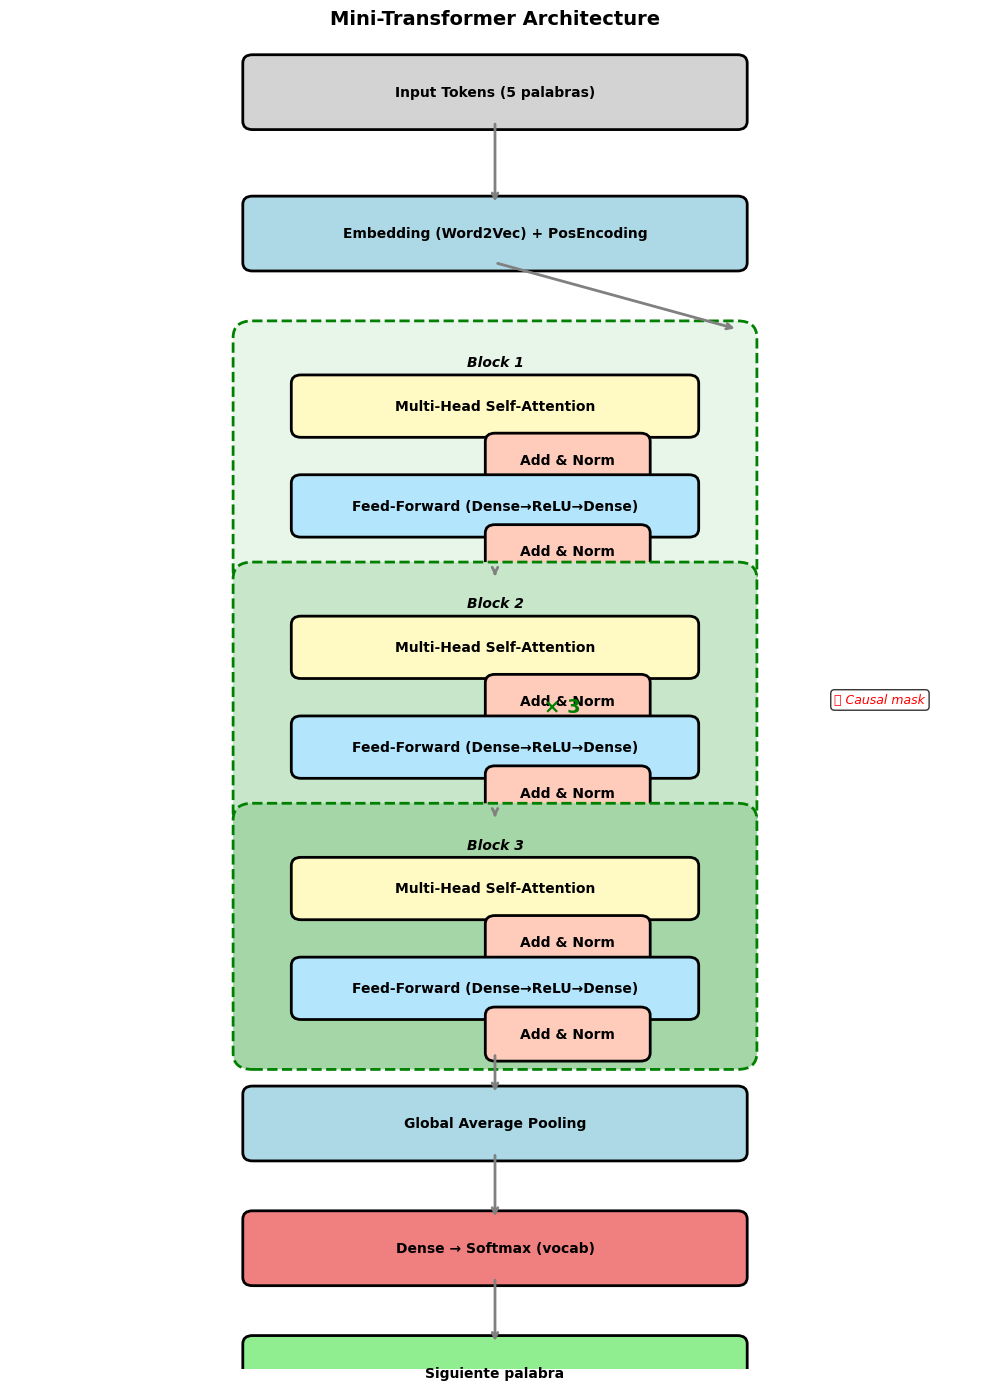

In [13]:
# Diagrama de arquitectura del mini-Transformer (similar a "Attention is All You Need")

def draw_architecture_diagram():
    fig, ax = plt.subplots(1, 1, figsize=(10, 14))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 16)
    ax.axis('off')

    def draw_box(ax, x, y, w, h, text, color='lightblue'):
        rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                        facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10, fontweight='bold')

    def draw_arrow(ax, x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

    cx = 5  # center x
    col1 = 2.5  # left column
    w = 5
    h = 0.7

    # Input
    draw_box(ax, col1, 15.0, w, h, 'Input Tokens (5 palabras)', 'lightgray')
    draw_arrow(ax, cx, 15.0, cx, 14.0)

    # Embedding + PosEncoding
    draw_box(ax, col1, 13.3, w, h, 'Embedding (Word2Vec) + PosEncoding', 'lightblue')
    draw_arrow(ax, cx, 13.3, cx + 2.5, 12.5)

    # x N blocks
    block_labels = ['Block 1', 'Block 2', 'Block 3']
    block_colors = ['#e8f5e9', '#c8e6c9', '#a5d6a7']
    bx = 2.5
    bw = 5
    bh = 2.8
    base_y = 9.6

    for i in range(3):
        y_off = base_y - i * 2.9
        color = block_colors[i]
        rect = mpatches.FancyBboxPatch((bx, y_off), bw, bh, boxstyle="round,pad=0.2",
                                       facecolor=color, edgecolor='green', linewidth=2, linestyle='--')
        ax.add_patch(rect)
        ax.text(bx + bw/2, y_off + bh - 0.3, block_labels[i],
                ha='center', va='center', fontsize=10, fontweight='bold', style='italic')

        # Sub-components inside block
        inner_w = 4
        inner_h = 0.55
        ix = bx + (bw - inner_w) / 2

        # Multi-Head Attention
        draw_box(ax, ix, y_off + 1.7, inner_w, inner_h,
                 'Multi-Head Self-Attention', '#fff9c4')
        # Add & Norm
        draw_box(ax, ix + 2, y_off + 1.1, inner_w - 2.5, 0.45,
                 'Add & Norm', '#ffccbc')
        # FFN
        draw_box(ax, ix, y_off + 0.5, inner_w, inner_h,
                 'Feed-Forward (Dense→ReLU→Dense)', '#b3e5fc')
        # Add & Norm
        draw_box(ax, ix + 2, y_off + 0.0, inner_w - 2.5, 0.45,
                 'Add & Norm', '#ffccbc')

        # Arrows between blocks
        if i < 2:
            y_next = base_y - (i+1) * 2.9 + bh
            draw_arrow(ax, cx, y_off, cx, y_next)

    draw_arrow(ax, cx, base_y - 2*2.9, cx, 3.3)

    # Pooling + Output
    draw_box(ax, col1, 2.6, w, h, 'Global Average Pooling', 'lightblue')
    draw_arrow(ax, cx, 2.6, cx, 1.8)

    draw_box(ax, col1, 1.1, w, h, 'Dense → Softmax (vocab)', 'lightcoral')
    draw_arrow(ax, cx, 1.1, cx, 0.3)

    draw_box(ax, col1, -0.4, w + 0.0, h, 'Siguiente palabra', 'lightgreen')

    # Annotation: x N
    ax.text(cx + 0.5, 7.9, '× 3', fontsize=14, fontweight='bold', color='green')

    # Causal mask annotation
    ax.text(8.5, 8.0, '🔒 Causal mask', fontsize=9, fontstyle='italic', color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.title('Mini-Transformer Architecture', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

draw_architecture_diagram()

In [14]:
# ManualSelfAttention con Causal Mask
# mask[i][j] = 1 si j <= i (lower triangular), 0 en caso contrario
# scores = scores * mask + (1 - mask) * -1e9  (softmax de los valores enmascarados da ~0)

class CausalSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, dropout_rate=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.Wq = layers.Dense(embed_dim, use_bias=False)
        self.Wk = layers.Dense(embed_dim, use_bias=False)
        self.Wv = layers.Dense(embed_dim, use_bias=False)
        self.Wo = layers.Dense(embed_dim, use_bias=False)
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x, return_attention=False):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        Q = tf.reshape(Q, (B, T, self.num_heads, self.head_dim))
        K = tf.reshape(K, (B, T, self.num_heads, self.head_dim))
        V = tf.reshape(V, (B, T, self.num_heads, self.head_dim))
        Q = tf.transpose(Q, [0, 2, 1, 3])
        K = tf.transpose(K, [0, 2, 1, 3])
        V = tf.transpose(V, [0, 2, 1, 3])

        scale = tf.sqrt(tf.cast(self.head_dim, tf.float32))
        scores = tf.matmul(Q, K, transpose_b=True) / scale

        # Causal mask: lower triangular
        mask = tf.linalg.band_part(tf.ones((T, T)), -1, 0)
        mask = tf.reshape(mask, (1, 1, T, T))
        scores = scores * mask + (1 - mask) * -1e9

        att_weights = tf.nn.softmax(scores, axis=-1)
        att_weights = self.dropout(att_weights)
        context = tf.matmul(att_weights, V)
        context = tf.transpose(context, [0, 2, 1, 3])
        context = tf.reshape(context, (B, T, self.num_heads * self.head_dim))
        out = self.Wo(context)
        if return_attention:
            att_avg = tf.reduce_mean(att_weights, axis=1)
            return out, att_avg
        return out


# Transformer Block = Self-Attention + Add&Norm + FFN + Add&Norm
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=4, ff_dim=128, dropout_rate=0.1):
        super().__init__()
        self.attention = CausalSelfAttention(embed_dim, num_heads, dropout_rate)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
            layers.Dropout(dropout_rate),
        ])

    def call(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_w = self.attention(x, return_attention=True)
        else:
            attn_out = self.attention(x)
            attn_w = None
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        if return_attention:
            return x, attn_w
        return x


# Mini Transformer = Embedding + PosEncoding + N Transformer Blocks + Pooling + Output
class MiniTransformer(keras.Model):
    def __init__(self, embedding_layer, vocab_size, embed_dim, seq_len=5,
                 num_heads=4, num_layers=3, ff_dim=128):
        super().__init__()
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_layers = num_layers

        self.embedding = embedding_layer
        self.pos_encoding = positional_encoding(seq_len, embed_dim)
        self.blocks = [TransformerBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)]
        self.pool = layers.GlobalAveragePooling1D()
        self.out = layers.Dense(vocab_size, activation='softmax')

    def call(self, inputs, return_attention=False):
        x = self.embedding(inputs)
        x = x + self.pos_encoding
        x = tf.nn.dropout(x, rate=0.1)

        attn_weights = None
        for i, block in enumerate(self.blocks):
            if return_attention and i == self.num_layers - 1:
                x, attn_w = block(x, return_attention=True)
                attn_weights = attn_w
            else:
                x = block(x)

        pooled = self.pool(x)
        logits = self.out(pooled)

        if return_attention:
            return logits, attn_weights
        return logits


vocab_size = loader.target_embeddings.shape[0]
model = MiniTransformer(
    loader.embedding_layer, vocab_size, loader.embedding_dim,
    seq_len=WINDOW, num_heads=4, num_layers=3, ff_dim=128
)

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.build((None, WINDOW))
model.summary()

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(min(len(X_train), 2000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

callbacks = [keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]

history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=1, callbacks=callbacks)

/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'mini_transformer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "mini_transformer_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ ?                      │       210,624 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,624 (822.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 210,624 (822.75 KB)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.1034 - loss: 6.9471 - val_accuracy: 0.1030 - val_loss: 6.7962
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.1053 - loss: 6.5804 - val_accuracy: 0.1030 - val_loss: 6.8298
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.1053 - loss: 6.4665 - val_accuracy: 0.1030 - val_loss: 6.7877
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.1052 - loss: 6.3070 - val_accuracy: 0.1030 - val_loss: 6.7056
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.1048 - loss: 6.1192 - val_accuracy: 0.1021 - val_loss: 6.6436
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.1050 - loss: 5.9160 - val_accuracy: 0.1019 - val_loss: 6.5663


Test accuracy (Mini Transformer, window=5, 3 layers): 0.103
Contexto ['london', 'bridge', 'river', 'city', 'center'] -> [('the', 0.11882295459508896), ('and', 0.043263182044029236), ('london', 0.037359148263931274), ('city', 0.009157746098935604), ('has', 0.00844187755137682)]
Contexto ['bank', 'of', 'england', 'is', 'located'] -> [('the', 0.1178034171462059), ('and', 0.042152680456638336), ('london', 0.036574769765138626), ('city', 0.008927412331104279), ('has', 0.008251728489995003)]
Contexto ['queen', 'of', 'england', 'lives', 'in'] -> [('the', 0.11960788071155548), ('and', 0.04341312125325203), ('london', 0.03821105882525444), ('city', 0.009287641383707523), ('has', 0.008557173423469067)]


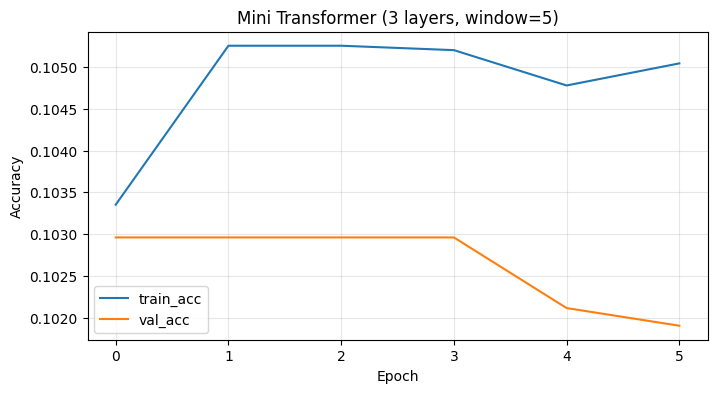

In [15]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy (Mini Transformer, window={WINDOW}, {model.num_layers} layers): {acc:.3f}')

def predict_next_word(context_words, top_n=5):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < WINDOW:
        context_ids = [0] * (WINDOW - len(context_ids)) + context_ids
    context_ids = np.array([context_ids[-WINDOW:]], dtype=np.int32)
    probs = model.predict(context_ids, verbose=0)[0]
    top_indices = np.argsort(probs)[-top_n:][::-1]
    return [(loader.decode(idx), float(probs[idx])) for idx in top_indices]

sample_contexts = [
    ['london', 'bridge', 'river', 'city', 'center'],
    ['bank', 'of', 'england', 'is', 'located'],
    ['queen', 'of', 'england', 'lives', 'in']
]

for context in sample_contexts:
    preds = predict_next_word(context, top_n=5)
    if preds:
        print(f"Contexto {context} -> {preds}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title(f'Mini Transformer ({model.num_layers} layers, window={WINDOW})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Primeras 5 palabras como contexto de prueba:
london the capital and largest


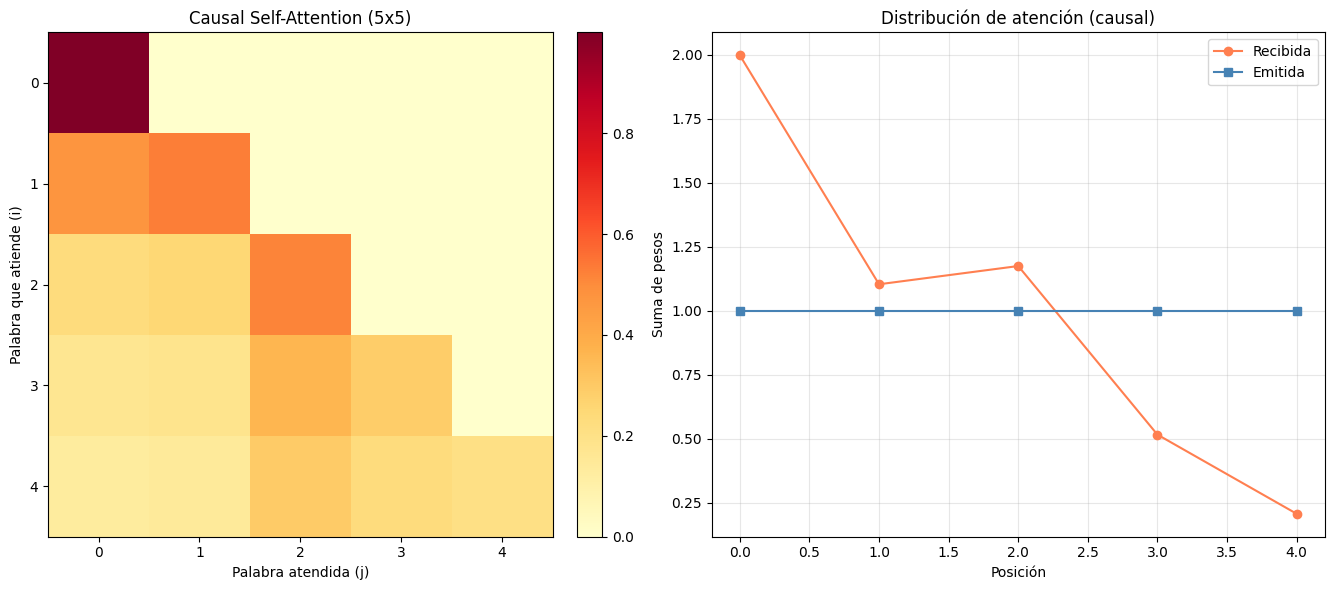

Diagonal (auto-atención): 0.5082
Triángulo inferior = atención causal (cada token solo ve previos)


In [16]:
# Heatmap de atención causal (último bloque)
def plot_causal_attention(context_words, model):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < WINDOW:
        context_ids = [0] * (WINDOW - len(context_ids)) + context_ids
    context_ids = np.array([context_ids[-WINDOW:]], dtype=np.int32)

    _, attn_avg = model(context_ids, return_attention=True)
    attn_matrix = attn_avg[0].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im = axes[0].imshow(attn_matrix, cmap='YlOrRd', vmin=0, vmax=attn_matrix.max())
    axes[0].set_title(f'Causal Self-Attention ({WINDOW}x{WINDOW})')
    axes[0].set_xlabel('Palabra atendida (j)')
    axes[0].set_ylabel('Palabra que atiende (i)')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    attended = attn_matrix.sum(axis=0)
    attending = attn_matrix.sum(axis=1)
    positions = np.arange(WINDOW)
    axes[1].plot(positions, attended, 'o-', label='Recibida', color='coral')
    axes[1].plot(positions, attending, 's-', label='Emitida', color='steelblue')
    axes[1].set_xlabel('Posición')
    axes[1].set_ylabel('Suma de pesos')
    axes[1].set_title('Distribución de atención (causal)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Diagonal (auto-atención): {np.trace(attn_matrix) / WINDOW:.4f}")
    print("Triángulo inferior = atención causal (cada token solo ve previos)")

sample_words = words[:WINDOW]
print("Primeras 5 palabras como contexto de prueba:")
print(' '.join(sample_words))
plot_causal_attention(sample_words, model)

## Comparación completa

| Notebook | Modelo | Window | Layers | Test Accuracy |
|----------|--------|:-----:|:------:|:------------:|
| 18 | RNN vanilla | 5 | 1 RNN | 0.403 |
| 19 | RNN + gradient clipping | 64 | 1 RNN | 0.420 |
| 20 | RNN + Bahdanau Attention | 5 | 1 RNN+Att | **0.575** |
| 21 | Self-Attention manual | 5 | 1 SA | 0.405 |
| 22 | Self-Attention manual | 32 | 1 SA | 0.104 |
| **23** | **Mini Transformer** | **5** | **3 SA+FFN** | **0.103** |

**Lo nuevo en 23:**
1. **Stacked layers** (3 bloques) — profundidad que faltaba en 22
2. **FFN por capa** — poder de cómputo no-lineal entre atenciones
3. **Causal mask** — atención triangular (como en GPT)
4. **Arquitectura de diagrama** — visualización del modelo completo